# Intro to librosa — exploring an *Angry* emotion clip

A quick tour of [librosa](https://librosa.org/) for audio analysis, using one of the
**Angry** `.wav` files from our `Emotions/` dataset.

We'll cover: loading audio, the waveform, spectrograms, mel-spectrograms, MFCCs,
and a few common features used for speech-emotion recognition.

> **Setup:** `pip install librosa matplotlib numpy` (librosa pulls in soundfile/audioread for decoding).

In [1]:
pip install librosa matplotlib numpy

  Using cached librosa-0.11.0-py3-none-any.whl.metadata (8.7 kB)
  Using cached audioread-3.1.0-py3-none-any.whl.metadata (9.0 kB)
  Using cached soundfile-0.13.1-py2.py3-none-macosx_11_0_arm64.whl.metadata (16 kB)
  Using cached pooch-1.9.0-py3-none-any.whl.metadata (10 kB)
  Using cached lazy_loader-0.5-py3-none-any.whl.metadata (5.9 kB)
Using cached librosa-0.11.0-py3-none-any.whl (260 kB)
Using cached audioread-3.1.0-py3-none-any.whl (23 kB)
Using cached lazy_loader-0.5-py3-none-any.whl (8.0 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 54.7 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.2/37.2 MB 66.8 MB/s  0:00:00 eta 0:00:01
Using cached pooch-1.9.0-py3-none-any.whl (67 kB)
Using cached soundfile-0.13.1-py2.py3-none-macosx_11_0_arm64.whl (1.1 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9/9 [librosa]m7/9 [numba]te]
Note: you may need to restart the kernel to use updated packages.


In [2]:
import librosa
import librosa.display
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Audio

print("librosa version:", librosa.__version__)

librosa version: 0.11.0


## 1. Load an audio file

`librosa.load` returns a 1-D NumPy array of samples `y` and the sample rate `sr`.
By default librosa resamples to 22,050 Hz and mixes down to mono — pass `sr=None`
to keep the file's native sample rate.

In [3]:
# Path is relative to the repo root. The Emotions/ folder is gitignored,
# so make sure you have the dataset locally.
audio_path = "../Emotions/Angry/03-01-05-01-01-01-01.wav"

y, sr = librosa.load(audio_path)

print(f"Samples shape : {y.shape}")
print(f"Sample rate   : {sr} Hz")
print(f"Duration      : {librosa.get_duration(y=y, sr=sr):.2f} s")

# Listen to it inline
Audio(data=y, rate=sr)

/opt/miniconda3/envs/ds_class/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Samples shape : (85346,)
Sample rate   : 22050 Hz
Duration      : 3.87 s


## 2. Waveform (amplitude over time)

The raw signal. Angry speech tends to be loud with sharp, high-energy bursts.

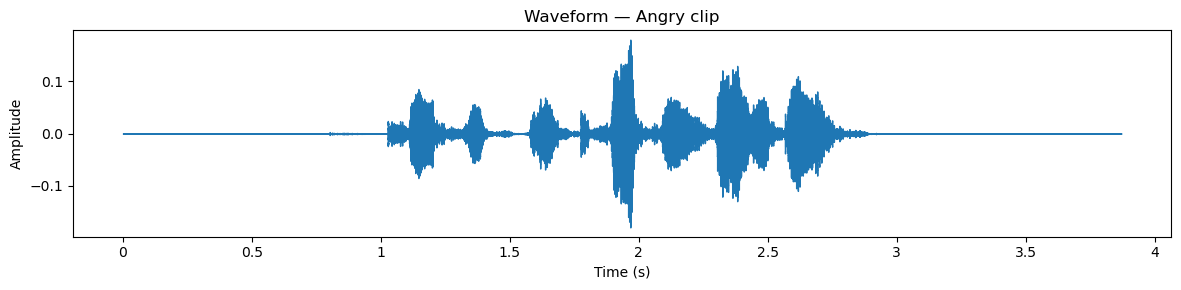

In [4]:
plt.figure(figsize=(12, 3))
librosa.display.waveshow(y, sr=sr)
plt.title("Waveform — Angry clip")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.tight_layout()
plt.show()

## 3. Spectrogram (STFT)

A spectrogram shows how the frequency content changes over time. We take the
Short-Time Fourier Transform and convert amplitude to decibels for visualization.

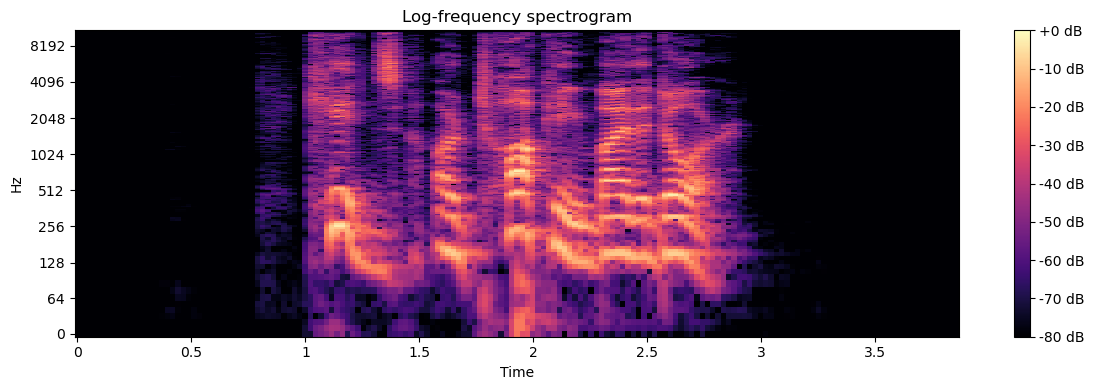

In [5]:
D = librosa.stft(y)                       # complex STFT
S_db = librosa.amplitude_to_db(np.abs(D), ref=np.max)

plt.figure(figsize=(12, 4))
img = librosa.display.specshow(S_db, sr=sr, x_axis="time", y_axis="log")
plt.colorbar(img, format="%+2.0f dB")
plt.title("Log-frequency spectrogram")
plt.tight_layout()
plt.show()

## 4. Mel-spectrogram

The mel scale spaces frequencies the way human hearing perceives pitch. Mel-spectrograms
(and their log) are one of the most common inputs to audio deep-learning models.

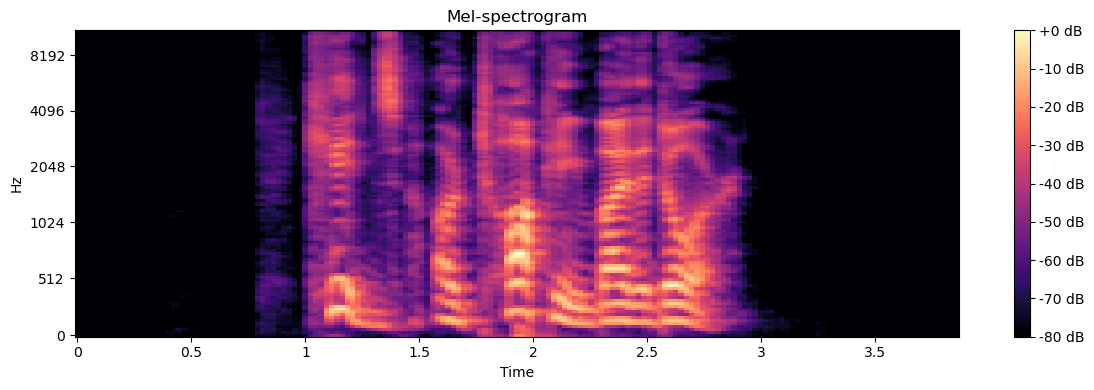

In [6]:
mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128)
mel_db = librosa.power_to_db(mel, ref=np.max)

plt.figure(figsize=(12, 4))
img = librosa.display.specshow(mel_db, sr=sr, x_axis="time", y_axis="mel")
plt.colorbar(img, format="%+2.0f dB")
plt.title("Mel-spectrogram")
plt.tight_layout()
plt.show()

## 5. MFCCs (Mel-Frequency Cepstral Coefficients)

MFCCs are a compact summary of the spectral envelope and a classic feature for
speech-emotion recognition. Here we extract 13 coefficients per frame.

MFCC shape (n_mfcc, frames): (13, 167)


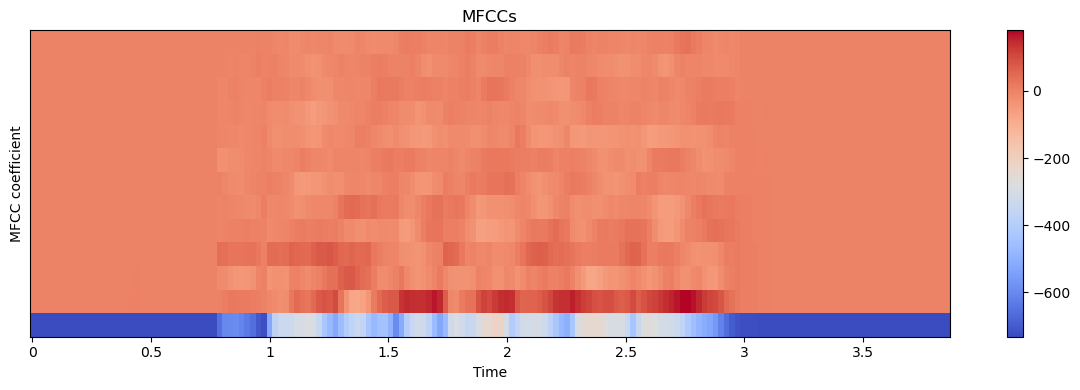

In [7]:
mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
print("MFCC shape (n_mfcc, frames):", mfccs.shape)

plt.figure(figsize=(12, 4))
img = librosa.display.specshow(mfccs, sr=sr, x_axis="time")
plt.colorbar(img)
plt.title("MFCCs")
plt.ylabel("MFCC coefficient")
plt.tight_layout()
plt.show()

## 6. A few more common features

- **Zero-crossing rate** — how often the signal changes sign (noisiness / percussiveness).
- **Spectral centroid** — the "center of mass" of the spectrum (perceived brightness).
- **RMS energy** — loudness over time.

Mean zero-crossing rate : 0.3336
Mean spectral centroid  : 3314.4 Hz
Mean RMS energy         : 0.0087


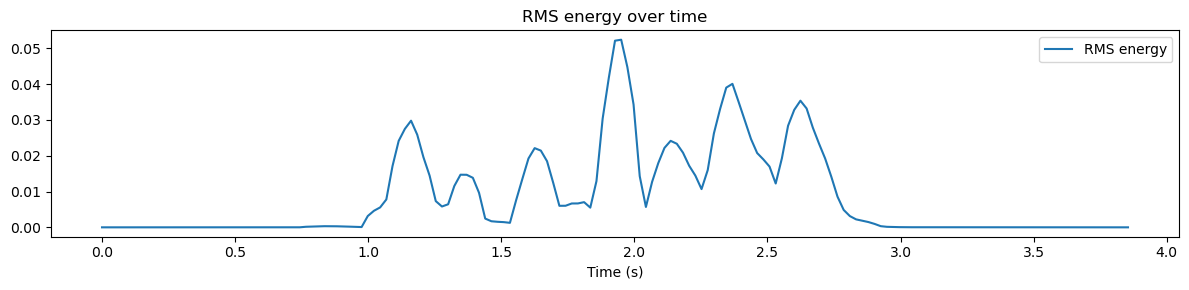

In [8]:
zcr      = librosa.feature.zero_crossing_rate(y)[0]
centroid = librosa.feature.spectral_centroid(y=y, sr=sr)[0]
rms      = librosa.feature.rms(y=y)[0]

print(f"Mean zero-crossing rate : {zcr.mean():.4f}")
print(f"Mean spectral centroid  : {centroid.mean():.1f} Hz")
print(f"Mean RMS energy         : {rms.mean():.4f}")

frames = range(len(rms))
t = librosa.frames_to_time(frames, sr=sr)

plt.figure(figsize=(12, 3))
plt.plot(t, rms, label="RMS energy")
plt.title("RMS energy over time")
plt.xlabel("Time (s)")
plt.legend()
plt.tight_layout()
plt.show()

## 7. Wrap it in a feature-extraction function

For modeling you typically reduce each clip to a fixed-length vector by averaging
features across time. This is a handy starting point for a classifier.

In [9]:
def extract_features(path, sr=22050, n_mfcc=13):
    """Load a wav file and return a 1-D feature vector (time-averaged)."""
    y, sr = librosa.load(path, sr=sr)
    mfccs    = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)
    chroma   = librosa.feature.chroma_stft(y=y, sr=sr)
    contrast = librosa.feature.spectral_contrast(y=y, sr=sr)
    zcr      = librosa.feature.zero_crossing_rate(y)
    rms      = librosa.feature.rms(y=y)
    return np.concatenate([
        mfccs.mean(axis=1),
        chroma.mean(axis=1),
        contrast.mean(axis=1),
        zcr.mean(axis=1),
        rms.mean(axis=1),
    ])

features = extract_features(audio_path)
print("Feature vector length:", features.shape[0])
print(features)

Feature vector length: 34
[-5.46115540e+02  4.25158081e+01 -6.01924324e+00  1.26451235e+01
 -1.40786290e+00 -2.79390979e+00 -4.31408739e+00 -1.45802832e+00
 -1.24570608e+01 -4.77724504e+00 -8.57797146e-01 -4.76682472e+00
 -7.10253119e-01  4.77794409e-01  5.48127592e-01  5.85361481e-01
  5.75921476e-01  4.96701807e-01  4.80874926e-01  4.77935344e-01
  4.35708374e-01  4.80205387e-01  5.64421058e-01  5.33867538e-01
  4.39131409e-01  1.87765988e+01  1.28113879e+01  1.54873739e+01
  1.47268565e+01  1.59061470e+01  1.72527763e+01  4.42429151e+01
  3.33572114e-01  8.67528562e-03]


### Next steps

- Loop over every file in `Emotions/<label>/` to build a feature matrix `X` and labels `y`.
- Train a baseline classifier (e.g. `sklearn`'s SVM or RandomForest) on the averaged features.
- Or feed mel-spectrograms directly into a CNN.

See the librosa docs for more: https://librosa.org/doc/latest/index.html